# **Maestría en Inteligencia Artificial Aplicada**

## **Curso: Inteligencia Artificial y Aprendizaje Automático**

**Tecnológico de Monterrey**

Prof Luis Eduardo Falcón Morales

Actividad de Semana 3

### **Rotación de Personal - IBM**

* **Nombre:** Lucía Alvarez Irigoyen

* **matrícula:** A01840750

------------

* #### **En esta actividad puedes apoyarte en uno o varios Modelos de Lenguaje de Gran Tamaño, LLM por sus siglas en inglés (Large Language Model). Indica claramente cuál o cuáles utilizaste.**

* #### **La siguiente actividad se basa en los datos del archivo "WA_Fn-UseC_-HR-Employee-Attrition.csv" que se encuentra en la siguiente liga de Kaggle, llamada "IBM HR Analytics Employee Attrition & Performance".**

* #### **Los datos los proporcionó IBM y aunque comentaron que por cuestiones de privacidad los datos son sintéticos, los generaron con base a su experiencia. Estos datos en general son referencia cuando se habla en Estadística o Aprendizaje Automático sobre el tema de rotación de personal.**

**El archivo contiene 1470 registros:**

https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset


**Declaración de uso de ML**
Utilicé Microsoft Copilot y ChatGPT como herramienta de apoyo para revisar conceptos de aprendizaje automático, interpretar métricas, revisar y depurar código, y mejorar la claridad de algunas explicaciones. Las decisiones sobre el procesamiento, modelado e interpretación de los resultados fueron revisadas con base en los resultados obtenidos en el notebook.

# **Ejercicio 1:**

#### **Incluye una breve introducción sobre lo que se entiende por el problema de rotación de personal en las organizaciones (employee attrition problem).**

++++++++ Inicia la sección de agregar texto: ++++++++++++

El problema de rotación personal o *attrition* se refiere a la salida voluntaria o involuntaria de los empleados en una organización. Esto genera costos de contratación, capacitación, pérdida de conocimiento de la organización y posibles impactos en la productividad y ambiente laboral. Desde el enfoque del aprendizaje automático, este problema puede analizar como un problema de clasificación binaria, en donde se busca predecir si un empleado permanecerá o no en la empresa, por medio de variables como la edad, salario, satisfación laboral, entre otros, con el objetivo de diseñar estrategias de retención de empleados.



++++++++ Termina la sección de agregar texto. +++++++++++

In [1]:
# Agrega aquí todas las librerías adicionales o paquetes que consideres necesarias:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier


from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.model_selection import cross_validate

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report, confusion_matrix



In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
DIR = "/content/drive/My Drive/Colab Notebooks/2do trimestre"
os.chdir(DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


* #### **Descarga el archivo de datos de la página de Kaggle.**

* #### **Cargamos el archivo como un DataFrame de Pandas y hacemos uso del método “describe” con el argumento include= “all” para desplegar información de todas las variables, numéricas y categóricas.**

In [3]:
path = "WA_Fn-UseC_-HR-Employee-Attrition.csv"
data = pd.read_csv(path)

print("Tamaño del DataFrame:", data.shape)
data.describe(include = 'all').T


Tamaño del DataFrame: (1470, 35)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1470.0,NaN,NaN,NaN,36.92381,9.135373,18.0,30.0,36.0,43.0,60.0
Attrition,1470,2,No,1233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BusinessTravel,1470,3,Travel_Rarely,1043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DailyRate,1470.0,NaN,NaN,NaN,802.485714,403.5091,102.0,465.0,802.0,1157.0,1499.0
Department,1470,3,Research & Development,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,1470.0,NaN,NaN,NaN,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
Education,1470.0,NaN,NaN,NaN,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
EducationField,1470,6,Life Sciences,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeCount,1470.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
EmployeeNumber,1470.0,NaN,NaN,NaN,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0


# **Ejercicio 2:**

**a) Realiza los análisis descriptivos y/o gráficos que creas adecuados para identificar 4 factores que se deben eliminar desde un inicio.**

**Al nuevo DataFrame sin las variables indicadas, llamarlo df.**



In [4]:
# a) Incluye a continuación el código y celdas que creas adecuados para responder a la pregunta.

# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++

# Número de valores únicos por columna
print(data.nunique())
print("\n")

# Identificar cual es el valor unico de las columnas EmployeeCount, Over18 y StandardHours
valor_unico_employee_count = data["EmployeeCount"].unique()
print(f"El único valor de la columna EmployeeCount es {valor_unico_employee_count}")
valor_unico_over_18 = data["Over18"].unique()
print(f"El único valor de la columna Over18 es {valor_unico_over_18}")
valor_unico_standard_hours = data["StandardHours"].unique()
print(f"El único valor de la columna StandardHours es {valor_unico_standard_hours}")

# La columna EmployeeNumber tiene 1470 registros, el mismo tamaño del dataFrame, por lo tanto se determina que
# es un identificador único, no tiene valor predictivo.

# Eliminar estas columnas porque no aportan variabilidad ni valor predictivo a los datos.
columnas_a_eliminar = ["EmployeeCount","Over18","StandardHours","EmployeeNumber"]

df = data.drop(columns = columnas_a_eliminar)
# ++++++++++ Termina sección para agregar código +++++++++++++++++++++++++++

# Verifiquemos de qué tamaño queda el nuevo DataFrame:
print("Tamaño del nuevo DataFrame:", df.shape)

Age                           43
Attrition                      2
BusinessTravel                 3
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EmployeeCount                  1
EmployeeNumber              1470
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
MonthlyRate                 1427
NumCompaniesWorked            10
Over18                         1
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StandardHours                  1
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimesLastYear          7
WorkLifeBa

**b) Con base a tu análisis anterior, indica cuáles fueron estas 4 variables y la justificación de por qué se pueden eliminar.**

++++++++ Inicia la sección de agregar texto: ++++++++++++

Se eliminaron las variables EmployeeCount, Over18 y Standards Hours, porque solamente tienen un valor único y esto no aporta variabilidad al análisis predictivo que queremos realizar. Además se eliminó EmployeeNumber, porque al tener 1470 registros únicos, sabemos que es un identificador único y no tiene valor predictivo para el modelo. Después de eliminar estas columnas, el dataframe tiene 1470 registros y 31 columnas.


  ++++++++ Termina la sección de agregar texto: ++++++++++++

# **Ejercicio 3:**

#### **Una vez eliminadas las variables no deseadas, clasifiquemos las restantes como se indica a continuación y en base a la información dada en la plataforma de Kaggle.**

#### **El número entre corcheas indica el número de variables de dicho tipo y el  número entre paréntesis redondos indica el número de niveles.**

* **Variables numéricas [14]:**

   * NumCompaniesWorked

   * TrainingTimesLastYear

   * Age

   * DailyRate

   * DistanceFromHome

   * HourlyRate

   * MonthlyIncome

   * MonthlyRate

   * PercentSalaryHike

   * TotalWorkingYears

   * YearsAtCompany

   * YearsInCurrentRole

   * YearsSinceLastPromotion

   * YearsWithCurrManager

* **Variables ordinales [9]:**

   * Education (5)

   * EnvironmentSatisfaction (4)

   * JobInvolvement (4)

   * JobLevel (5)

   * JobSatisfaction (4)

   * PerformanceRating (2)

   * RelationshipSatisfaction (4)

   * StockOptionLevel (4)

   * WorkLifeBalance (4)

* **Variables binarias [3]:**

   * Attrition (variable de salida)

   * Gender

   * OverTime

* **Variables nominales [5]:**

   * BusinessTravel (3)

   * Department (3)

   * EducationField (6)

   * JobRole (9)

   * MaritalStatus (3)

In [5]:
# Crear lista de variables de acuerdo con la clasificación de Kaggle

# Variables numéricas (14)
variables_num = [
    "NumCompaniesWorked",
    "TrainingTimesLastYear",
    "Age",
    "DailyRate",
    "DistanceFromHome",
    "HourlyRate",
    "MonthlyIncome",
    "MonthlyRate",
    "PercentSalaryHike",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager"
]

# Variables ordinales (9)
variables_ord = [
    "Education",
    "EnvironmentSatisfaction",
    "JobInvolvement",
    "JobLevel",
    "JobSatisfaction",
    "PerformanceRating",
    "RelationshipSatisfaction",
    "StockOptionLevel",
    "WorkLifeBalance"
]

# Variables binarias (2)
variables_bin = [
    "Gender",
    "OverTime"
]

# Variables nominales (5)
variables_nom = [
    "BusinessTravel",
    "Department",
    "EducationField",
    "JobRole",
    "MaritalStatus"
]


**Indpendientemente de los factores que al final el modelo identifique como los factores más importantes a considerar en este problema de rotación de personal ¿qué preocupaciones éticas o legales podrían generarse, si algunos de estos factores más importantes a considerar para tomar decisiones sobre los empleados fueran la edad (Age), el género (Gender) o el estado civil (Marital Status)?**


++++++++ Inicia la sección de agregar texto: ++++++++++++

Si se usan variables como edad, género o estado civil, puede ocasionar una discriminación directa hacia el empleado, ya que los datos podrían generar patrones discriminatorios y crear un sesgo para quien utilice el modelo. Estas características no reflejan el desempeño ni las habilidades de un empleado y utilizar estos datos personales podría generar desconfianza y preocupación por su privacidad. Actualmente existen leyes contra la discriminación por estas características del empleado.

++++++++ Termina la sección de agregar texto. +++++++++++


# **Ejercicio 4:**

**a) Aunque este problema como está planteado es un problema de clasificación binaria, ¿qué otros enfoques analíticos podrían plantearse y modelarse a partir de este problema? Menciona al menos dos más.**



++++++++ Inicia la sección de agregar texto: ++++++++++++

Un enfoque analítico es el de regresión para calcular cuanto tiempo permanecerá el empleado en la empresa, i.e., años en la compañía. Este análisis podría ayudar a identificar el riesgo de salida anticipada y diseñar estrategias de retención.

Otro enfoque es de clustering o agrupación, para hacer segmentación de perfiles. Con este enfoque es posible encontrar patrones ocultos y agrupar a los empleados con perfil de alto riesgo para aplicar una estrategia de retención específica por grupo. Algunas variables útiles para agrupar podrían ser DistanceFromHome, YearsInCurrentRole, WorkLifeBalance, OverTime, entre otras.


  ++++++++ Termina la sección de agregar texto: ++++++++++++

### **Para esta actividad usaremos una partición en Train, Val y Test, con los porcentajes que se indican a continuación.**

In [6]:
print("Dimensiones y Porcentajes de la partición Train+Validation+Test generada:")
print("-"*75)

X = df.drop(columns='Attrition')
y = df[['Attrition']]

Xtrain, Xtv, ytrain, ytv = train_test_split(X, y, train_size=0.70, stratify=y, random_state=17)
Xval, Xtest, yval, ytest = train_test_split(Xtv, ytv, test_size=0.5, stratify=ytv, random_state=17)

print("Variables de entrada Train, Validation, Test:")
print(Xtrain.shape, '%.1f%%' % (100.*Xtrain.shape[0]/X.shape[0]))
print(Xval.shape, '%.1f%%' % (100.*Xval.shape[0]/X.shape[0])),
print(Xtest.shape, '%.1f%%' % (100.*Xtest.shape[0]/X.shape[0]))

print("\nVariables de salida Train, Validation, Test:")
print(ytrain.shape)
print(yval.shape)
print(ytest.shape)

Dimensiones y Porcentajes de la partición Train+Validation+Test generada:
---------------------------------------------------------------------------
Variables de entrada Train, Validation, Test:
(1029, 30) 70.0%
(220, 30) 15.0%
(221, 30) 15.0%

Variables de salida Train, Validation, Test:
(1029, 1)
(220, 1)
(221, 1)


# **Ejercicio 5:**


**a) Aplica la transformación LabelEncoder() de Sklearn a la variable“Attrition”, tomando en cuenta los siguientes puntos:**

* **Las nuevas variables deberán llamarse ahora: ytrainT, yvalT, ytestT.**

* **Al aplicar la transformación LabelEncoder deberás evitar el filtrado de información (data-leakage).**


In [7]:
# a)
# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++

le = LabelEncoder()

# Ajustar el codificador solo con los datos de entrenamiento ytrain
le.fit(ytrain["Attrition"])

# Crear dataframes para guardar los resultados de la transformación
ytrainT = pd.DataFrame()
yvalT = pd.DataFrame()
ytestT = pd.DataFrame()

# Transformar las tres particiones de entrenamiento, validación y prueba
ytrainT["Attrition"] = le.transform(ytrain["Attrition"])
yvalT["Attrition"] = le.transform(yval["Attrition"])
ytestT["Attrition"] = le.transform(ytest["Attrition"])

# Imprimir y verificar resultados
print("Clases codificadas:", le.classes_)

# +++++++++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++

print('Porcentaje de datos en cada clase del conjunto de entrenamiento (Train):\n', ytrainT['Attrition'].value_counts() / ytrainT.shape[0])

Clases codificadas: ['No' 'Yes']
Porcentaje de datos en cada clase del conjunto de entrenamiento (Train):
 Attrition
0    0.838678
1    0.161322
Name: count, dtype: float64


#### Además, responde las siguientes preguntas:

**b) Con base a la documentación actual de Sklearn, ¿a qué tipo de variables se recomienda aplicar la transformación LabelEncoder?**

**c) Con base al contexto del problema, ¿qué significan los valores 0 (NO) y 1 (YES) de la variable de salida Attrition?**

**d) Con base a la información obtenida y considerando la métrica de la exactitud (accuracy) ¿cuál será el valor del umbral del modelo base o ingenuo (baseline, naive) a superar para evitar tener un modelo subentrenado una vez que empecemos a generarlos?**

**e) Indica si el desbalanceo de clases obtenido puede ya considerarse como un problema, y de considerarlo así, qué otra métrica o métricas podrían ser más adecuadas que la exactitud (accuracy).**



++++++++ Inicia la sección de agregar texto: ++++++++++++

b) Según la documentación de Scikit-learn, la transformación LabelEncoder se recomienda utilizar para codificar variables categóricas que representan etiquetas de clase, es decir, las que son variables objetivo (y) y no de entrada (x).

c) 0 (No) significa que el empleado no dejó la empresa y 1 (Yes) que el empleado sí dejó la empresa.

d) El conjunto de entrenamiento presenta aproximadamente 83.87% de empleados en la clase No y 16.13% en la clase Yes. Por lo tanto, un clasificador que predijera la clase mayoritaria "No" tendría una exactitud / accuracy aproximada de 83.87%. Este será el umbral del modelo base a superar para evitar que el modelo esté subentrenado.

e) Existe un desbalance importante entre las clases, por esta razón, la exactitud por sí sola puede resultar engañosa, ya que un modelo que siempre predijera "No" tendría aproximadamente 83.9% de accuracy sin identificar correctamente a los empleados que abandonan la empresa.

Por ello, podemos utilizar las métricas:
* Recall o Sensibilidad: tasa de verdaderos positivos, cuantos empleados que se van fueron identificados correctamente. VP / (VP + FN)
* Precisión: cuantos empleados predichos como que se van, realmente se van. VP / (VP + FP)
* F1-score: la combinación de precisión y sensibilidad en una sola métrica, se recomienda para clases desbalanceadas, como en este ejercicio.

++++++++ Termina la sección de agregar texto. +++++++++++

# **Ejercicio 6:**


#### **Incluye a continuación un análisis gáfico y descriptivo que consideres adecuado.**

  * **a) El análisis debe ser suficiente para que te ayude a tomar las decisiones sobre qué transformaciones aplicar a cada variable antes de entrenar los modelos.**

  * **b) Además, para obtener mayor información sobre la relación entre variables, incluye un gráfico de barras de frecuencias ordenadas de mayor a menor, de la variable "Age", únicamente para los casos de empleados que ya no están en la compañía (Attrition=Yes).**

  * **c) Incluye también un gráfico de barras ordenado de la relación entre Education y Attrition=Yes. Muestra además en el gráfico las etiquetas asociadas a Education en lugar de los números, como se indica en la página de Kaggle.**

  * **d) [Opcional] Incluye algún otro gráfico o gráficos que consideres aporta información para el análisis y entendimiento del problema. Si no encuentras algún otro gráfico de interés, deberas indicarlo.**

  * **e) Para la empresa de IBM ¿qué es más costoso? ¿clasificar erróneamente a un empleado que sí renunciará, o por el contrario, generar una falsa alarma?**


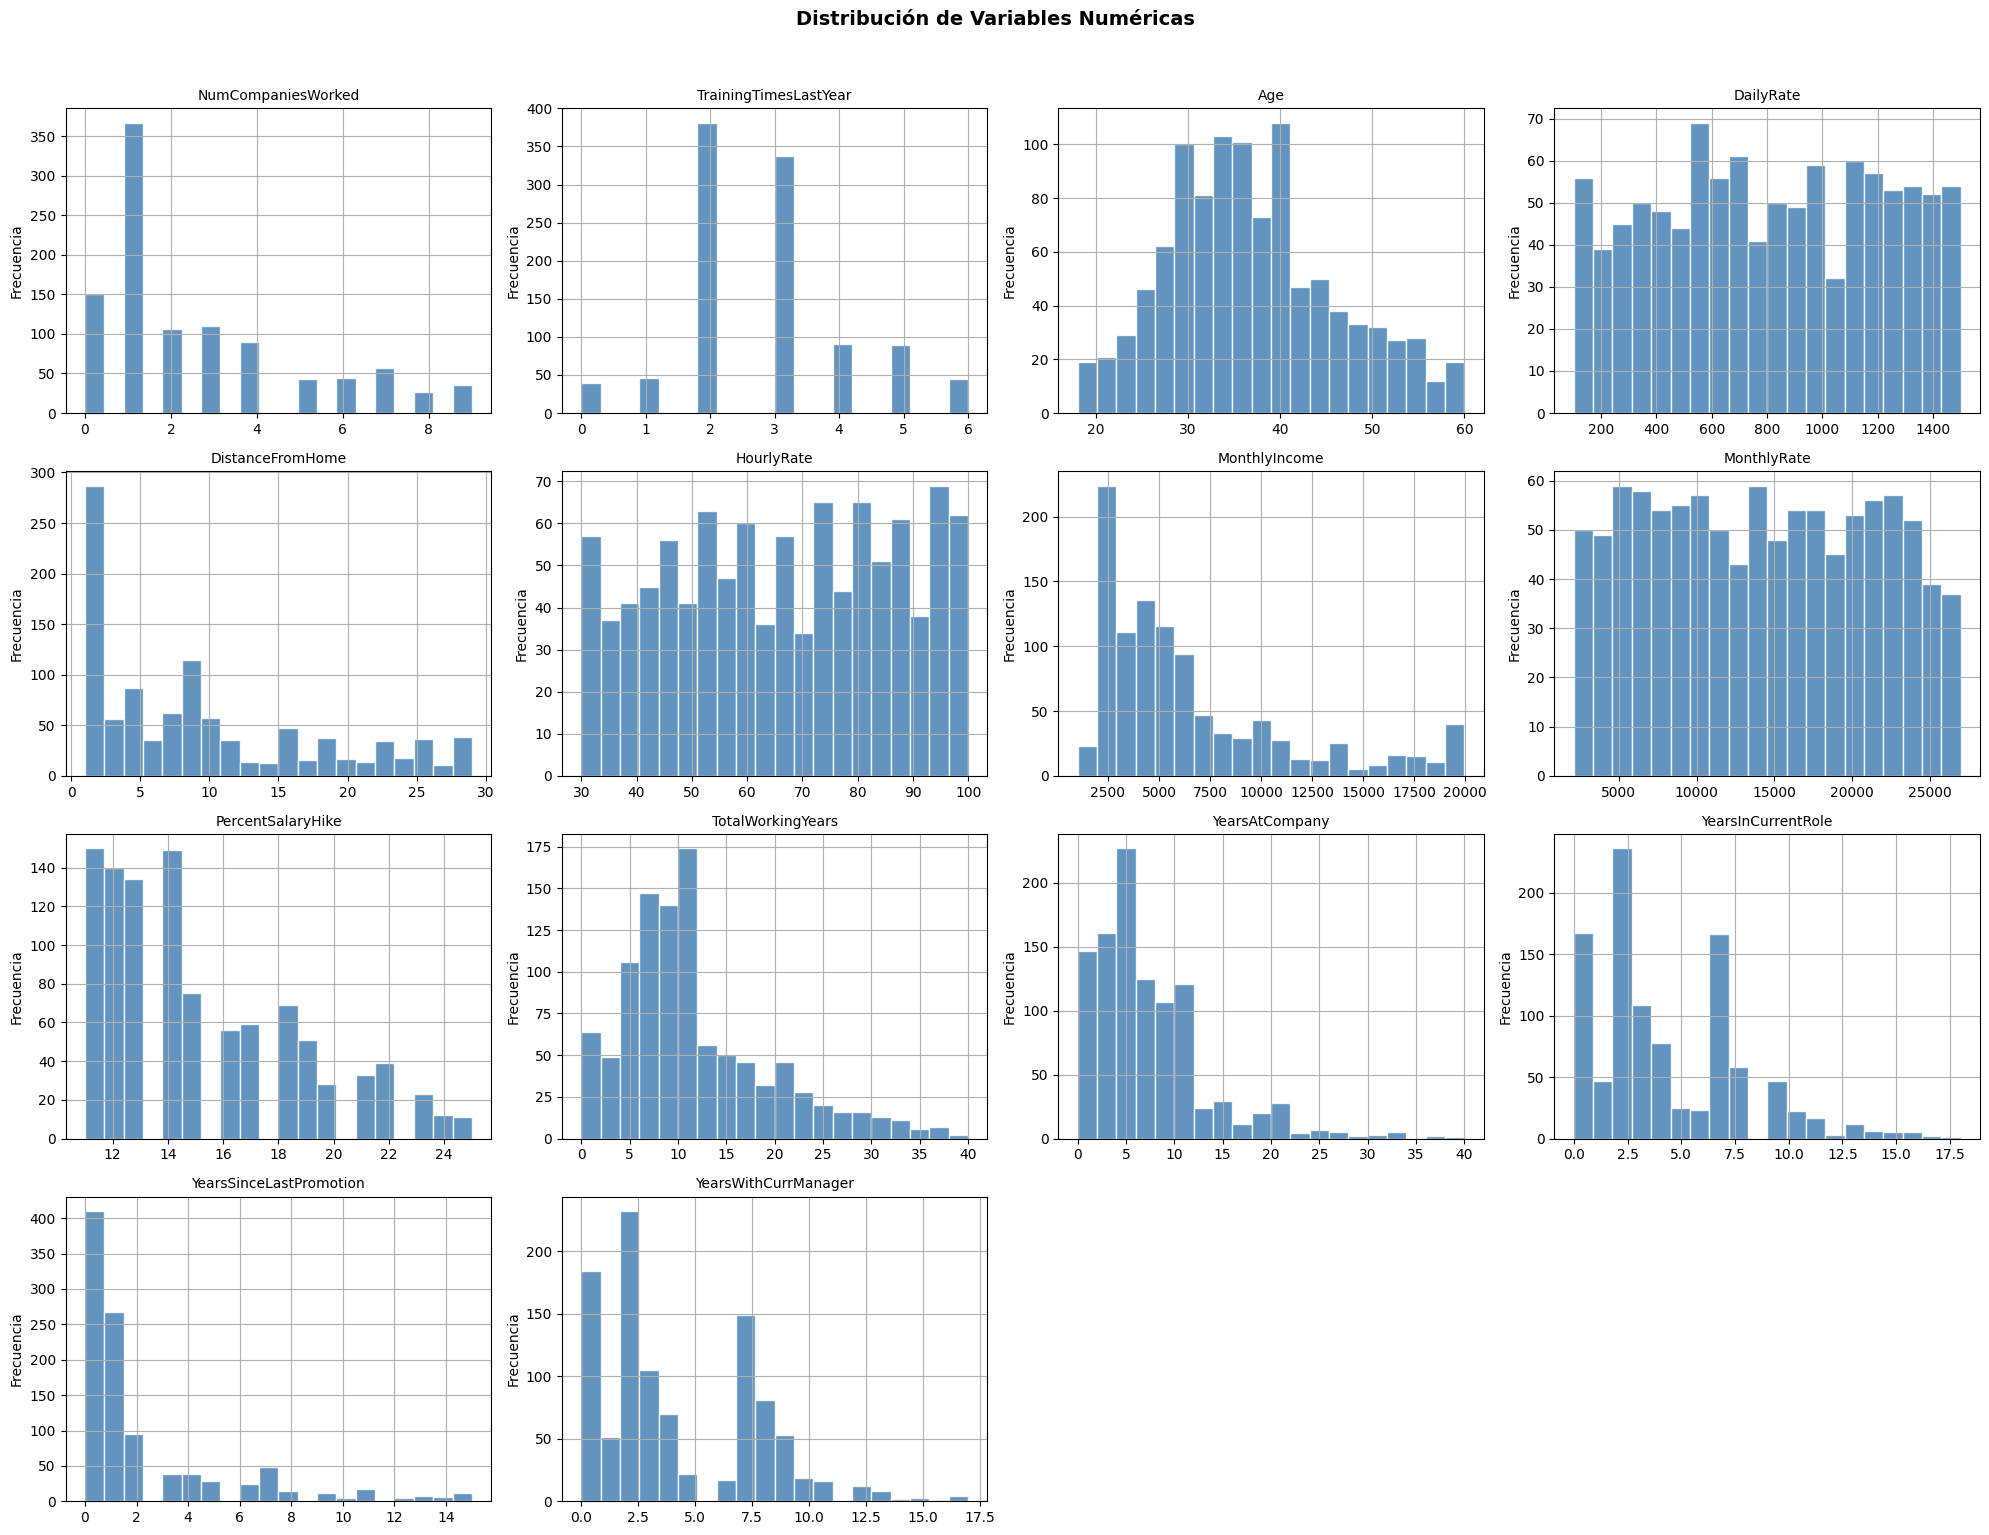

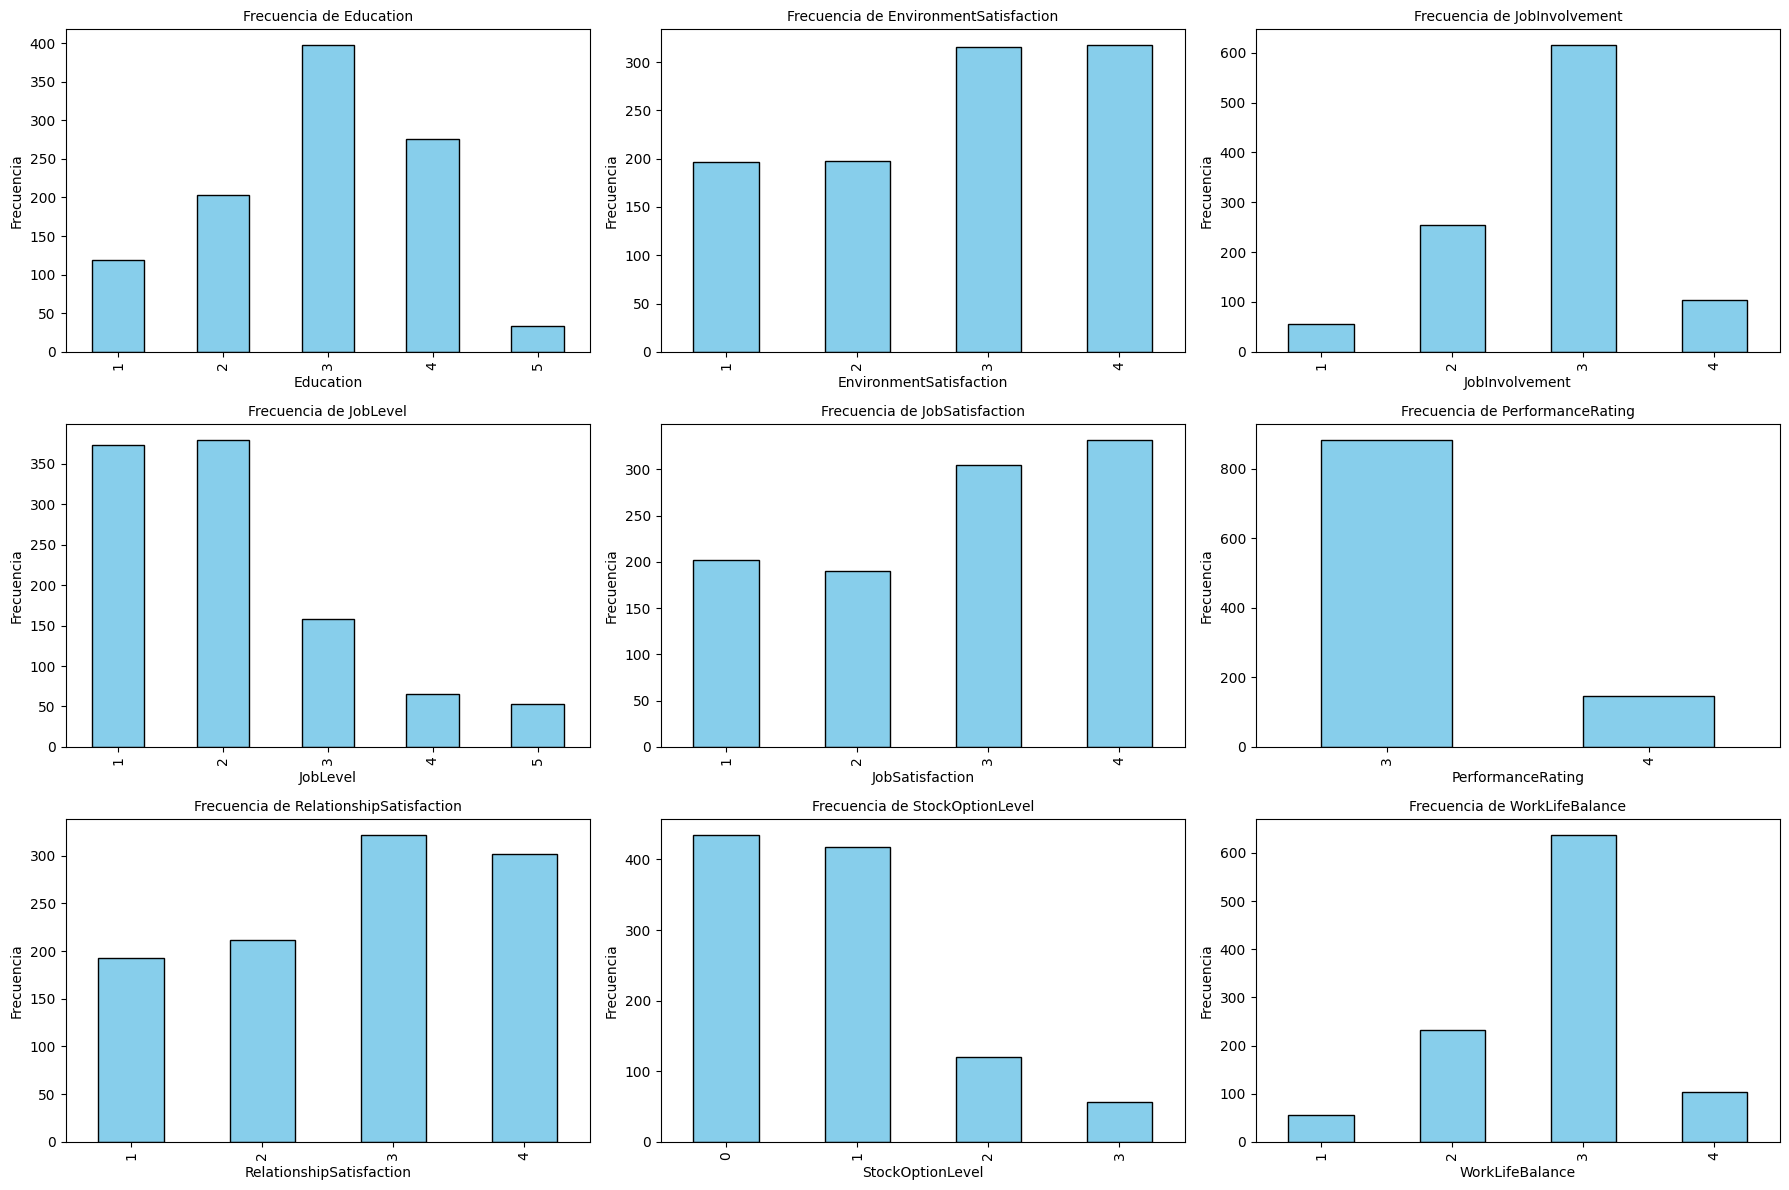

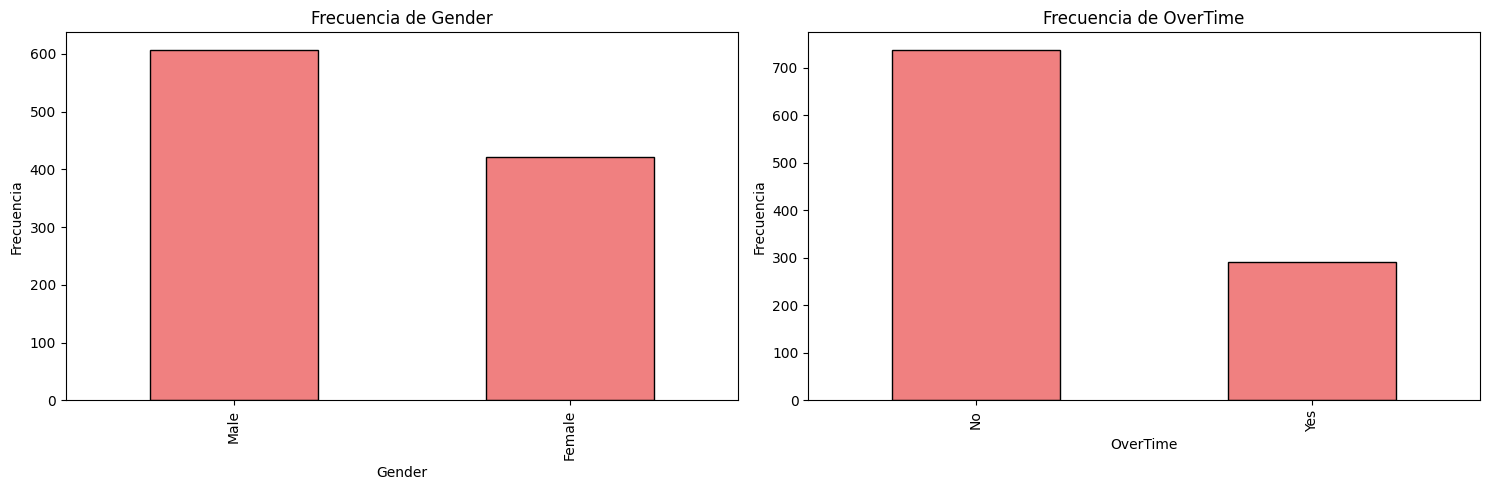

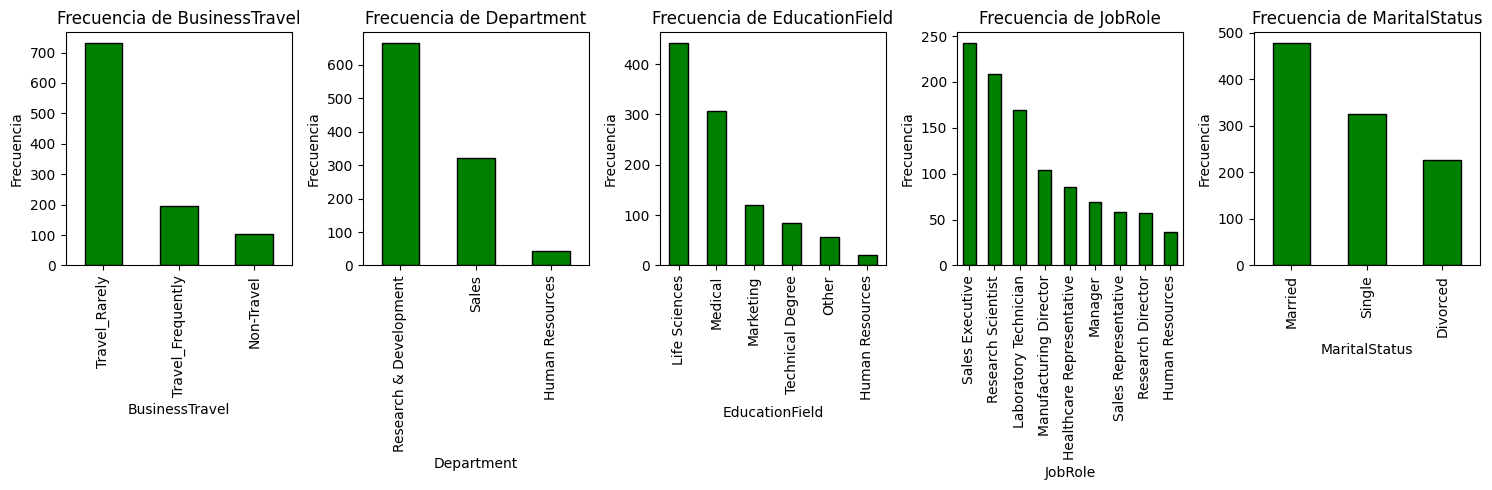

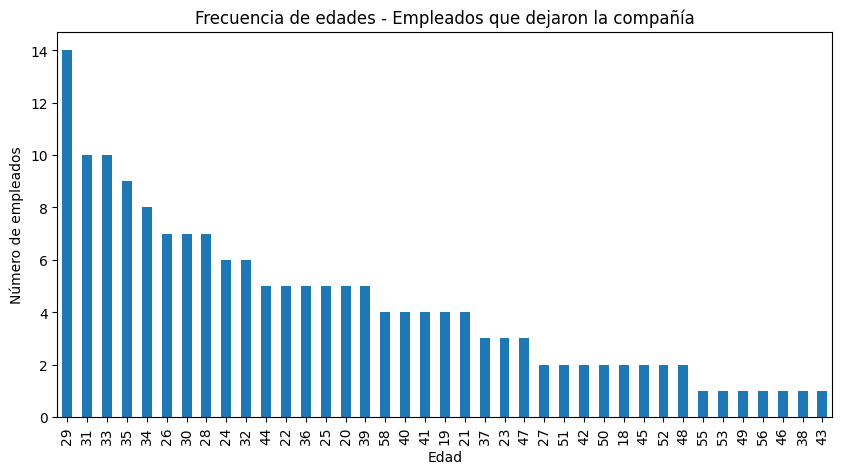

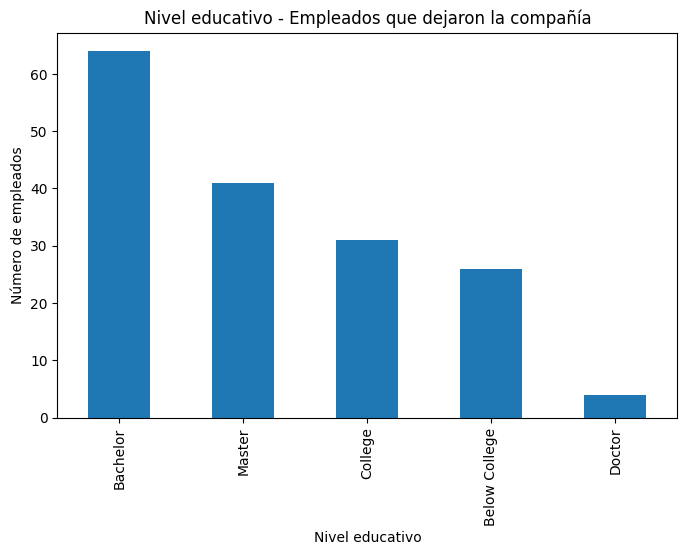

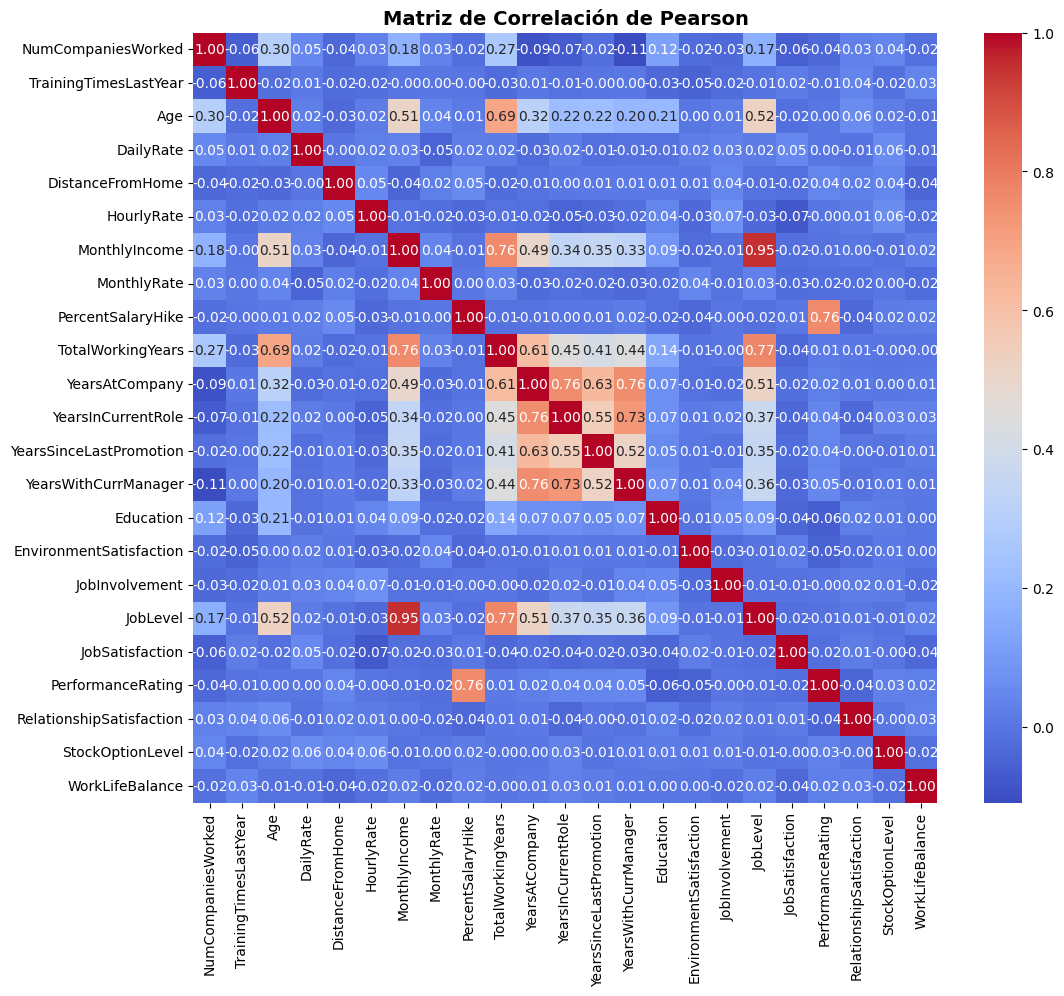

In [8]:

# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++
# Incluye en esta sección todas las celdas que consideres necesarias.

# a) Análsis y gráficos

df_train = pd.concat([Xtrain, ytrain], axis=1)

# Graficar variables numéricas
plt.figure(figsize=(20, 15))
for i, col in enumerate(variables_num, 1):
    plt.subplot((len(variables_num) // 4) + 1, 4, i)
    Xtrain[col].hist(bins=20, color='steelblue', edgecolor='white', alpha=0.85)
    plt.title(col, fontsize=10)
    plt.xlabel('')
    plt.ylabel('Frecuencia')

plt.suptitle('Distribución de Variables Numéricas', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#Graficar variables ordinales
plt.figure(figsize=(18, 12))
for i, col in enumerate(variables_ord, 1):
    plt.subplot(3, 3, i)
    Xtrain[col].value_counts().sort_index().plot(kind="bar", color="skyblue", edgecolor="black")
    plt.title(f"Frecuencia de {col}", fontsize=10)
    plt.xlabel(col)
    plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

#Graficar variables binarias
plt.figure(figsize=(15, 5))
for i, col in enumerate(variables_bin, 1):
    plt.subplot(1, len(variables_bin), i)  # una fila, tantas columnas como variables
    Xtrain[col].value_counts().plot(kind="bar", color="lightcoral", edgecolor="black")
    plt.title(f"Frecuencia de {col}", fontsize=12)
    plt.xlabel(col)
    plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

#Graficar variables nominales
plt.figure(figsize=(15, 5))
for i, col in enumerate(variables_nom, 1):
    plt.subplot(1, len(variables_nom), i)  # una fila, tantas columnas como variables
    Xtrain[col].value_counts().plot(kind="bar", color="green", edgecolor="black")
    plt.title(f"Frecuencia de {col}", fontsize=12)
    plt.xlabel(col)
    plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()


# b) Gráfico age-attrition[yes]

# Filtrar empleados que se fueron
df_yes = df_train[df_train['Attrition'] == 'Yes']
# Conteo de edades ordenado
age_count = df_yes['Age'].value_counts().sort_values(ascending=False)
# Gráfico
plt.figure(figsize=(10,5))
age_count.plot(kind='bar')
plt.title("Frecuencia de edades - Empleados que dejaron la compañía")
plt.xlabel("Edad")
plt.ylabel("Número de empleados")
plt.show()

# c) Gráfico education-attrition[yes]

# En Kaggle, los niveles de Education están definidos como:
# 1 = Below College, 2 = College, 3 = Bachelor, 4 = Master, 5 = Doctor.
# Filtrar empleados que se fueron
education_count = df_yes['Education'].value_counts().sort_index()
# Mapear etiquetas
edu_labels = {1:"Below College", 2:"College", 3:"Bachelor", 4:"Master", 5:"Doctor"}
education_count.index = education_count.index.map(edu_labels)
# Gráfico
plt.figure(figsize=(8,5))
education_count.sort_values(ascending=False).plot(kind='bar')
plt.title("Nivel educativo - Empleados que dejaron la compañía")
plt.xlabel("Nivel educativo")
plt.ylabel("Número de empleados")
plt.show()




# d) [gráfico opcional]

variables_num_ord = variables_num + variables_ord

corr_matrix = Xtrain[variables_num_ord].corr(method="pearson")

# Matriz de correlación de Pearson
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix,
            annot=True,        # muestra los valores numéricos
            fmt=".2f",         # formato con 2 decimales
            cmap="coolwarm",   # paleta de colores
            cbar=True)

plt.title("Matriz de Correlación de Pearson", fontsize=14, fontweight="bold")
plt.show()



# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++



**Conclusiones del análisis exploratorio y decisiones de transformación**

El análisis muestra que las variables numéricas se encuentran en escalas diferentes, por lo que es conveniente estandarizarlas antes de utilizar modelos sensibles a la escala, particularmente Regresión Logística y KNN.

Las variables ordinales presentan categorías con un orden natural, por lo que se conservará dicho orden mediante OrdinalEncoder.

Las variables binarias tienen únicamente dos categorías, por lo que serán transformadas mediante OneHotEncoder eliminando una categoría, para evitar redundancia.

Las variables nominales no presentan un orden natural, por lo que se utilizará OneHotEncoder. Se utilizará además handle_unknown='ignore' para hacer el pipeline robusto ante categorías no observadas durante el entrenamiento.

Estas transformaciones se encapsularán posteriormente utilizando Pipeline y ColumnTransformer para evitar inconsistencias y reducir el riesgo de filtración de información.

**e) ¿Qué es más costoso, los Falsos Negativos o los Falsos Positivos?**

++++++++ Inicia la sección de agregar texto: ++++++++++++


Es más costoso un Falso Negativo, es decir, clasificar de forma errónea que un empleado sí renunciará porque no se anticipa la baja, se pierde conocimiento y experiencia sin estar preparados, y se generan costos de reemplazo y capacitación. En cambio, un falso positivo / falsa alarma, implica que se podría haber generado un gasto de retención innecesario, pero es de menor costo en comparación a perder al empleado.



++++++++ Termina la sección de agregar texto: ++++++++++++

# **Ejercicio 7:**

#### **Utiliza las clases Pipeline y ColumnTransformer de Sklearn para definir las transformaciones que deberás aplicar a cada variable y de acuerdo a su tipo considerado previamente.**



In [9]:
# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++


# NUMÉRICAS con MinMaxScaler:
numericas_pipeline = Pipeline(steps=[
    ('inputer', SimpleImputer(strategy='median')),
    ("scaler", MinMaxScaler())
])
numericas_pipeline_nombres = variables_num

# ORDINALES con OrdinalEncoder:
catOrd_pipeline = Pipeline([
    ("ordinal", OrdinalEncoder())
])
catOrd_pipeline_nombres = variables_ord

# BINARIAS con OneHotEncoder:
catBin_pipeline = Pipeline(
    steps = [('impModa', SimpleImputer(strategy='most_frequent')),
             ('onehot', OneHotEncoder(drop='if_binary'))]
)
catBin_pipeline_nombres = variables_bin

# NOMINALES:
catNom_pipeline = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
catNom_pipeline_nombres = variables_nom

# ============================
# ColumnTransformer general
# ============================
columnasTransformer = ColumnTransformer([
    ("num", numericas_pipeline, numericas_pipeline_nombres),
    ("ord", catOrd_pipeline, catOrd_pipeline_nombres),
    ("bin", catBin_pipeline, catBin_pipeline_nombres),
    ("nom", catNom_pipeline, catNom_pipeline_nombres)
])



# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++

**Justificación de las transformaciones**

Para las variables numéricas se utiliza MinMaxScaler, ya que las variables se encuentran en escalas diferentes. Esta transformación lleva las variables a una escala comparable, lo cual resulta conveniente para modelos sensibles a la escala como Regresión Logística y KNN. Además, al realizar la transformación dentro del Pipeline, el escalamiento se ajusta únicamente con los datos de entrenamiento correspondientes a cada partición de validación cruzada.

Para las variables ordinales se utiliza OrdinalEncoder, ya que sus categorías tienen un orden natural. De esta manera se conserva la información ordinal de los niveles.

Para las variables binarias se utiliza OneHotEncoder(drop='if_binary'), eliminando una de las categorías para evitar redundancia en la representación.

Para las variables nominales se utiliza OneHotEncoder(handle_unknown='ignore'), ya que sus categorías no tienen un orden natural. Además, handle_unknown='ignore' permite que el pipeline pueda procesar categorías que eventualmente no hayan aparecido durante el entrenamiento.

* #### **Vamos a utilizar validación cruzada, por lo que decidimos para esta actividad reagrupar los conjuntos de entrenamiento y validación en un solo DataFrame.**

* #### **Al resultado obtenido los llamaremos Xtv y ytv.**


In [10]:
Xtv = pd.concat([Xtrain, Xval], axis=0)
ytv = pd.concat([ytrainT, yvalT], axis=0)


print("Dimensión del conjunto Train+Val:")
print(Xtv.shape)
print(ytv.shape)

Dimensión del conjunto Train+Val:
(1249, 30)
(1249, 1)


# **Ejercicio 8:**

#### **Entrenamiento y ajuste de hiperparámetros**

#### **a) Busca los mejores hiperparámetros para cada modelo, de manera que no estén subentrenados con respecto a la métrica de la exactitud (accuracy).**

#### **b) Incluye tus comentarios sobre el resultado obtenido.**



#### **NOTA-1: En dado caso, cuando mucho uno de los modelos podría quedar subentrenado.**

#### **NOTA-2: Por el momento estamos usando la métrica de la exactitud (accuracy). El objetivo de esta actividad es que sepas entrenar modelos sin que resulten subentrenados o sobreentrenados, independientemente de la métrica a considerar. En próximas semanas seguiremos con el estudio de las otras métricas para abordar de mejor manera los problemas y obtener mejores resultados.**

En relación a la variante de Validación Cruzada "RepeatedStratifiedKFold" utilizada en este ejercicio, puedes consultar la siguiente liga:

  https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RepeatedStratifiedKFold.html


>> LR 0.883 (0.019)
>> LASSO 0.890 (0.016)
>> RIDGE 0.890 (0.015)
>> EN 0.890 (0.014)
>> KNN 0.847 (0.011)


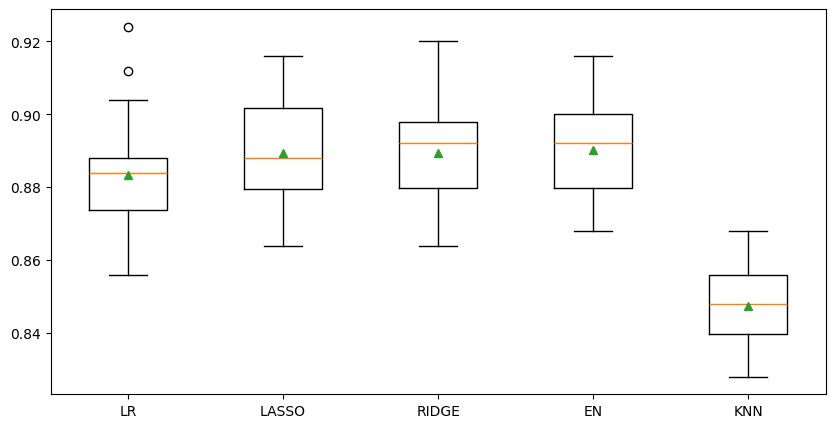

In [11]:
# 8a) Ajuste de hiperparámetros.
#     En cada modelo que utilcemos a continuación, utiliza la semilla "random_state=1"
#     indicada, para obtener la repetibilidad de los resultados en la manera de lo
#     posible. Es decir, este argumento y valor no deberás modificarlo.

# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++


def mis_modelos():
  modelos, nombres = list(), list()

  # LR - Regresión Logística sin regularización:
  modelos.append(LogisticRegression(penalty=None,  # Este valor de "Nonemodelo sin regularización." no lo debes cambiar. Define al
                                    solver='lbfgs',     # Incluye aquí todos los hiperparámetros y valores que consideres adecuados.
                                    max_iter=1000,
                                    random_state=1
                                    ))
  nombres.append('LR')



  # Lasso - Regresión Logística con regularización L1:
  modelos.append(LogisticRegression(penalty='l1',
                                    solver='saga',     # Incluye aquí todos los hiperparámetros y valores que consideres adecuados.
                                    C=1.0,
                                    max_iter=1000,
                                    random_state=1))
  nombres.append('LASSO')



  # Ridge - Regresión Logística con regularización L2:
  modelos.append(LogisticRegression(penalty='l2',
                                    solver='lbfgs',     # Incluye aquí todos los hiperparámetros y valores que consideres adecuados.
                                    C=1.0,
                                    max_iter=1000,
                                    random_state=1))
  nombres.append('RIDGE')



  # Elastic_Net - - Regresión Logística con regularización L1 y L2:
  modelos.append(LogisticRegression(penalty='elasticnet',
                                    solver='saga',     # Incluye aquí todos los hiperparámetros y valores que consideres adecuados.
                                    l1_ratio=0.5,
                                    C=1.0,
                                    max_iter=1000,
                                    random_state=1))
  nombres.append('EN')



  # KNN - K-Vecinos más cercanos:
  modelos.append(KNeighborsClassifier(n_neighbors=5,      # Numero de vecinos # Incluye aquí todos los hiperparámetros y valores que consideres adecuados.
                                      weights='uniform',  # todos los vecinos pesan igual
                                      metric='minkowski', # métrica estándar (distancia Euclídea)
                                      p=2                 # parámetro para Minkowski (p=2 -> Euclídea)
                                      ))
  nombres.append('KNN')

  return modelos, nombres




# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++


# Pasamos al entrenamiento de los modelos.
# Hay obviamente varias maneras de llevar a cabo el entrenamiento,
# pero por el momento supongamos que lo hacemos de la manera siguiente:

modelos, nombres = mis_modelos()  # accesando los modelos.
resultados = list()    # para guardar los resultados en esta lista.

# Iterando y entrenando sobre cada modelo:
for i in range(len(modelos)):

  pipeline = Pipeline(steps=[('ct',columnasTransformer),('m',modelos[i])])   # Conjuntamos Transformaciones y modelos en un Pipeline.

  cv1 = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=7)     # Aplicando una de las variantes de Validación Cruzada.

  scores = cross_val_score(pipeline, Xtv, np.ravel(ytv), scoring='accuracy', cv=cv1)   # Entrenando y generando los resultados con la exactitud (accuracy).


  resultados.append(scores)    # Guardamos los resultados en la lista.
  print('>> %s %.3f (%.3f)' % (nombres[i], np.nanmean(scores), np.nanstd(scores)))  # Desplegando los promedios de cada modelo.


plt.figure(figsize=(10,5))
plt.boxplot(resultados, tick_labels=nombres, showmeans=True)   # Gráficos de caja para una comparación visual de los resultados.
plt.show()


**8b) Comentarios sobre los resultados y modelos obtenidos. En particular indica cuál consideras el mejor modelo. ¿Alguno quedó subentrenado y ya no se pudo mejorar su desempeño?**

++++++++ Inicia la sección de agregar texto: ++++++++++++


Modelos lineales (LASSO, RIDGE, Elastic Net):  
Todos alcanzan un desempeño muy similar, con accuracy ≈ 0.890 y desviaciones estándar bajas (≈0.014–0.016). Esto indica que son modelos estables y consistentes.

Elastic Net (EN) destaca ligeramente porque tiene la desviación estándar más baja (0.014), lo que significa que sus resultados son los más consistentes entre las repeticiones de validación cruzada.

LASSO y RIDGE también son muy competitivos, con la misma exactitud pero un poco más de variabilidad.

Logistic Regression sin regularización (LR):  
Se queda un poco atrás con 0.883, aunque sigue siendo un modelo sólido.

KNN:  
Tiene una exactitud más baja (0.847) y menos adecuado para este dataset. Aunque funciona, su desempeño es limitado frente a los modelos lineales, aunque no está subentrenado porque el accuracy alcanza el umbral de 0.838.


++++++++ Termina la sección de agregar texto: ++++++++++++


# **Ejercicio 9:**

* #### **Utiliza el mejor modelo encontrado en el paso anterior, los datos Xtv, ytv, y realiza ahora una búsqueda de malla con validación cruzada para tratar de mejorar el desempeño de este modelo.**

* #### **Sigue utilizando la métrica de la exactitud (accuracy).**

* #### **Verifica además que el modelo no esté subentrenado o sobreentrenado.**

* #### **Llama "resultado_malla" al mejor modelo ajustado.**




* **NOTA-1: Para esta actividad diremos que el modelo no está sobreentrenado si la diferencia entre Train y Validation es menor al 3%.**


* **NOTA-2: Puedes utilizar GridSearchCV, o bien, RandomizedSearchCV. La documentación la puedes consultar en las siguientes ligas:**

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html


In [12]:
# +++++++++ Inicia sección para incluir tu código ++++++++++++++++++++++++


# Seleccionamos Elastic Net como nuestro mejor modelo.
modelo = LogisticRegression(penalty='elasticnet',
                            solver='saga',
                            max_iter=2000,
                            random_state=1)

# Definimos la rejilla de hiperparámetros a probar
dicc_grid = {
    'm__C': [0.1, 0.5, 1.0, 3.0, 10.0],
    'm__l1_ratio': [0.1, 0.2, 0.5, 0.8, 0.9]
}

# Pipeline completo: transformación + modelo
pipeline_malla = Pipeline(steps=[
    ('ct', columnasTransformer),
    ('m', modelo)
])


cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=3,
    random_state=1
)

# Configuración de GridSearchCV
grid = GridSearchCV(
    estimator=pipeline_malla,
    param_grid=dicc_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    return_train_score=True
)

# Entrenamos con los datos de entrenamiento
resultado_malla = grid.fit(
    Xtv,
    np.ravel(ytv)
)

# Guardamos el mejor modelo ajustado
mejor_resultado = resultado_malla.best_estimator_

# +++++++++ Termina sección para incluir tu código ++++++++++++++++++++++++

print("Desempeño del mejor modelo con la métrica de Exactitud (Accuracy)")
print("-"*65)
print("Mejor modelo: %f usando los hiperparámetros %s" % (resultado_malla.best_score_, resultado_malla.best_params_))
print('Promedios Train mean(std): %.2f%% (%.4f%%)' % (100*np.nanmean(resultado_malla.cv_results_['mean_train_score']),
                                                 100*np.nanmean(resultado_malla.cv_results_['std_train_score'])))
print('Promedios Val mean(std): %.2f%% (%.4f%%)' % (100*resultado_malla.cv_results_['mean_test_score'].mean(),
                                               100*resultado_malla.cv_results_['std_test_score'].mean()))


Desempeño del mejor modelo con la métrica de Exactitud (Accuracy)
-----------------------------------------------------------------
Mejor modelo: 0.890327 usando los hiperparámetros {'m__C': 0.5, 'm__l1_ratio': 0.5}
Promedios Train mean(std): 89.58% (0.3541%)
Promedios Val mean(std): 88.27% (1.5352%)


# **Ejercicio 10:**

#### **Finalmente, usando el conjunto de prueba (Test) responde los siguientes incisos:**

#### **a) Obtener el desempeño final del mejor modelo con el reporte de métricas classification_report() de Sklearn.**

#### **b) Obtener la matriz de confusión del mejor modelo.**

#### **c) Indica como se leen o interpretan los valores VP, VN, FP, FN obtenidos y de acuerdo al contexto del problema.**

#### **d) Realiza un análisis de importancia de los factores o características e incluye tus comentarios.**



In [13]:
# a) Reporte del desempeño con classification_report():

# +++++++++ Inicia sección para incluir tu código ++++++++++++++++++++++++

# a) Reporte de métricas en Test
y_pred = mejor_resultado.predict(Xtest)

print("Reporte de métricas en Test:")
print(
    classification_report(
        ytestT['Attrition'],
        y_pred,
        target_names=le.classes_
    )
)

# +++++++++ Termina sección para incluir tu código ++++++++++++++++++++++++


Reporte de métricas en Test:
              precision    recall  f1-score   support

          No       0.88      0.96      0.92       185
         Yes       0.61      0.31      0.41        36

    accuracy                           0.86       221
   macro avg       0.74      0.63      0.66       221
weighted avg       0.83      0.86      0.83       221



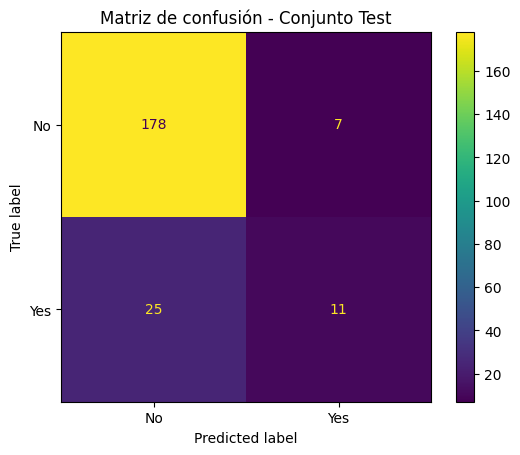

In [14]:
# b) Matriz de confusión:

# +++++++++ Inicia sección para incluir tu código ++++++++++++++++++++++++

# b) Matriz de confusión
# Predicciones sobre Test
y_pred = mejor_resultado.predict(Xtest)

# Matriz de confusión
ConfusionMatrixDisplay.from_predictions(
    ytestT['Attrition'],
    y_pred,
    display_labels=le.classes_
)

plt.title("Matriz de confusión - Conjunto Test")
plt.show()

# +++++++++ Termina sección para incluir tu código ++++++++++++++++++++++++


*  c) Interpretación de VP, VN, FP, FN.
#### +++++++++ Inicia sección para incluir tus comentarios ++++++++++++++++++++++++

None


* **VP:** 11, número de empleados que sí dejaron la compañía y fueron clasificados correctamente por el modelo como "Yes".

* **VN:** 178, número de empleados que no dejaron la compañía y fueron clasificados correctamente por el modelo como "No".

* **FP:** 7, número de empleados que no dejaron la compañía y el modelo los clasificó incorrectamente como "Yes".

* **FN:** 25, número de empleados que sí dejaron la compañía y el modelo los clasifico incorrectamente como "No".

#### +++++++++ Termina sección para incluir tus comentarios ++++++++++++++++++++++++

In [15]:
# 10d) Importancia de factores

# +++++++++ Inicia sección para incluir tu código ++++++++++++++++++++++++

# Modelo final dentro del Pipeline
modelo_final = mejor_resultado.named_steps['m']

# ColumnTransformer utilizado dentro del Pipeline
columnasTransformer_final = mejor_resultado.named_steps['ct']

# Coeficientes
coef = modelo_final.coef_[0]

# Nombres de las variables transformadas
feature_names = columnasTransformer_final.get_feature_names_out()

# Importancia y Odds Ratio
importancia = pd.DataFrame({
    'Variable': feature_names,
    'Coeficiente': coef,
    'Importancia': abs(coef),
    'OddsRatio': np.exp(coef)
}).sort_values(
    by='Importancia',
    ascending=False
)

print("Top 15 variables más influyentes:")
print(importancia.head(15))


# +++++++++ Termina sección para incluir tu código ++++++++++++++++++++++++



Top 15 variables más influyentes:
                                  Variable  Coeficiente  Importancia  \
24                       bin__OverTime_Yes     1.892090     1.892090   
12            num__YearsSinceLastPromotion     1.269070     1.269070   
11                 num__YearsInCurrentRole    -1.181785     1.181785   
2                                 num__Age    -1.170230     1.170230   
0                  num__NumCompaniesWorked     1.115625     1.115625   
4                    num__DistanceFromHome     1.104606     1.104606   
26   nom__BusinessTravel_Travel_Frequently     0.861589     0.861589   
3                           num__DailyRate    -0.768681     0.768681   
39      nom__JobRole_Laboratory Technician     0.725950     0.725950   
48               nom__MaritalStatus_Single     0.708383     0.708383   
13               num__YearsWithCurrManager    -0.647967     0.647967   
25          nom__BusinessTravel_Non-Travel    -0.625141     0.625141   
29  nom__Department_Research &

*  **10d) Comentarios sobre los resultados sobre el análisis de importancia de factores o características**

#### +++++++++ Inicia sección para incluir tus comentarios ++++++++++++++++++++++++
Un coeficiente positivo está asociado con un incremento en la probabilidad de pertenecer a la clase Yes (Attrition), mientras que un coeficiente negativo está asociado con una menor probabilidad, manteniendo constantes las demás variables. La magnitud absoluta del coeficiente se utiliza como indicador de importancia dentro del modelo.

Nota: se agregó el Odds Ratio para facilitar la interpretación de los coeficientes de la regresión logística y expresar cuánto aumentan o disminuyen las odds de Attrition.

**Factores principales**

* El factor con mayor coeficiente positivo es OverTime_Yes, con un coeficiente de +1.892. Esto indica una asociación positiva entre trabajar horas extra y la probabilidad estimada de pertenecer a la clase Yes. Su Odds Ratio es aproximadamente 6.63, por lo que, dentro de este modelo y manteniendo constantes las demás variables, la categoría OverTime=Yes está asociada con mayores odds de pertenecer a la clase de empleados que abandonan la empresa.

* YearsSinceLastPromotion presenta un coeficiente positivo de +1.269 y un Odds Ratio de aproximadamente 3.56. Esto indica una asociación positiva entre esta variable y la probabilidad estimada de Attrition.

* NumCompaniesWorked presenta un coeficiente positivo de +1.116, mientras que DistanceFromHome presenta un coeficiente positivo de +1.105. Ambas variables muestran una asociación positiva con la probabilidad estimada de Attrition.

* Entre los factores con coeficientes negativos destacan YearsInCurrentRole (-1.182) y Age (-1.170). Sus Odds Ratios son aproximadamente 0.31, lo que indica una asociación negativa con las odds de pertenecer a la clase Yes.

* También YearsWithCurrManager (-0.648) presenta una asociación negativa con Attrition, mientras que TrainingTimesLastYear (-0.614) presenta una asociación negativa más moderada.

* Entre las variables categóricas, BusinessTravel_Travel_Frequently (+0.862) y JobRole_Laboratory Technician (+0.726) presentan asociaciones positivas con la clase Yes. Asimismo, MaritalStatus_Single (+0.708) presenta una asociación positiva.

* En términos generales, los resultados sugieren que factores relacionados con las horas extra, el tiempo desde la última promoción, el número de compañías en las que se ha trabajado y la distancia desde casa están asociados positivamente con la rotación. Por otro lado, variables como la edad, los años en el rol actual y los años con el mismo manager presentan asociaciones negativas.

* Estos resultados representan asociaciones del modelo y no relaciones causales. Por lo tanto, no se puede concluir que una variable por sí sola provoque la renuncia de un empleado.

En términos de acción empresarial, esto sugiere que para reducir la rotación conviene:

* Promover movilidad interna y oportunidades de crecimiento.
* Controlar la carga de horas extra.
* Ofrecer apoyo en balance vida-trabajo y transporte.
* Fomentar relaciones estables con líderes y managers.
#### +++++++++ Termina sección para incluir tus comentarios ++++++++++++++++++++++++

# **Ejercicio 11:**


### **Para terminar, responde las siguientes preguntas relacionadas con las implicaciones involucradas con la toma de decisiones basadas en los resultados de un modelo de aprendizaje automático. El objetivo es reflexionar sobre estas implicaciones y no dudes en compartir tus experiencias en caso de que te hayas enfrentado a una situación similar en tu trabajo.**

* **a) Si tu modelo predice e identifica con un alto porcentaje de exactitud quiénes de los colaboradores de la empresa estarán abandonando su puesto muy pronto, ¿cómo debería usarse esa información? Al responder, considera que es importante cuidar la parte ética y de privacidad de la información del colaborador.**

* **b) Con base a los resultados de la matriz de confusión, ¿qué tipo de error (FN o FP) está considerando como más costoso el modelo? En particular, ¿coincide con la respuesta que diste en el Ejercicio 6e?**

* **c) ¿Cómo comunicarías los resultados del modelo obtenido en esta actividad a un público no técnico, es decir, sin los conocimientos de temas de aprendizaje automático. Por ejemplo, supongamos que vas a comunicarle tus resultados a los directivos de la empresa o al personal del área de Recursos Humanos.**

* **d) ¿En cuáles ejercicios anteriores consideras que el (o los) modelo de lenguaje de gran tamaño LLM utilizado fue de mayor ayuda? ¿Por qué?**

* **e) Incluye tus conclusiones finales de la actividad.**

---

#### +++++++++ Inicia sección para incluir tus conclusiones ++++++++++++++++++++++++


* a) Si el modelo predice con alta exactitud quiénes podrían abandonar la empresa, esa información debe usarse con responsabilidad ética y respeto a la privacidad.

No se trata de “etiquetar” o “vigilar” a los colaboradores, sino de anticipar riesgos y diseñar estrategias de retención.

Ejemplos de uso correcto: ofrecer programas de desarrollo, revisar cargas de trabajo, mejorar condiciones laborales, abrir oportunidades de promoción.

Es fundamental comunicar a los empleados que los datos se usan para mejorar su experiencia laboral, no para sancionarlos ni discriminar.

* b) En la matriz de confusión los FN (Falsos Negativos) fueron más altos que los VP.

FN = empleados que sí se van, pero el modelo los predice como “No”.

Este error es más costoso porque la empresa pierde talento sin haber tomado medidas preventivas.

Coincide con lo que mencionamos en el ejercicio 6e: en contextos críticos, los FN son más peligrosos que los FP.

Los FP (falsas alarmas) implican invertir recursos en retención de alguien que no se iba a ir, lo cual es menos grave que perder a alguien valioso.

* c) Para directivos o RRHH, lo importante es traducir los resultados en acciones prácticas:

El modelo nos ayuda a identificar patrones que aumentan la probabilidad de renuncia, como exceso de horas extra, falta de promociones y distancia desde casa.

No es perfecto, pero nos da señales tempranas para actuar.

El objetivo no es predecir con exactitud absoluta, sino reducir riesgos de rotación y mejorar la satisfacción de los colaboradores.

Usar gráficos simples (ej. barras con factores más influyentes, matriz de confusión en colores) en lugar de métricas técnicas.

* d) Los LLM fueron fueron de mayor ayuda principalmente en los ejercicios relacionados con la interpretación de resultados, como la matriz de confusión, las métricas de clasificación y la importancia de factores. También fueron útiles para revisar el código de preprocesamiento y detectar posibles problemas relacionados con el pipeline y la filtración de información. Sin embargo, los resultados numéricos finales fueron obtenidos mediante la ejecución del notebook y no mediante el LLM.

* e) El modelo Elastic Net mostró buen desempeño, pero aún con riesgo de FN altos. Por lo tanto, incluso con accuracy de 86% en Test, el modelo solamente identifica correctamente aproximadamente el 31% de los empleados que efectivamente abandonaron.

La importancia de factores como años sin promoción, horas extra y distancia desde casa refleja problemas reales de gestión de talento.

La exactitud es útil, pero en contextos humanos lo más relevante es minimizar errores críticos (FN) y usar el modelo como apoyo, no como sustituto de decisiones humanas.

La ética y la comunicación clara son tan importantes como la técnica: un modelo de predicción de rotación debe verse como una herramienta para mejorar la experiencia laboral, no para controlar o sancionar.

#### +++++++++ Termina sección para incluir tus conclusiones ++++++++++++++++++++++++

# >> **Fin de la Actividad de Rotación de Personal de la Semana 3** <<